In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [10]:
df = pd.read_csv('~/Downloads/online_retail.csv')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [11]:
# Data Cleaning

df = df.drop_duplicates()

df = df.dropna(subset=['CustomerID'])

df = df[
    (df['Quantity'] > 0) &
    (df['UnitPrice'] > 0)
]

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

df.shape

(392692, 9)

In [12]:
# Exploratory Sales Analysis

summary_stats = {
    'Total Revenue': df['TotalAmount'].sum(),
    'Average Transaction Value': df['TotalAmount'].mean(),
    'Max Transaction Value': df['TotalAmount'].max(),
    'Min Transaction Value': df['TotalAmount'].min(),
    'Total Customers': df['CustomerID'].nunique(),
    'Total Orders': df['InvoiceNo'].nunique()
}

summary_stats

{'Total Revenue': np.float64(8887208.894000001),
 'Average Transaction Value': np.float64(22.631499735161402),
 'Max Transaction Value': 168469.6,
 'Min Transaction Value': 0.001,
 'Total Customers': 4338,
 'Total Orders': 18532}

### Insight

The cleaned dataset contains 4,338 unique customers and 18,532 orders, generating total revenue of approximately £8.89M.

In [13]:
top_products_by_revenue = (
    df.groupby('Description')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products_by_revenue

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalAmount, dtype: float64

In [14]:
country_revenue = (
    df.groupby('Country')['TotalAmount']
      .sum()
      .sort_values(ascending=False)
)

country_revenue.head(10)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: TotalAmount, dtype: float64

Because the UK dominates the dataset, a separate analysis excluding the UK was created to better compare international markets.

In [15]:
country_revenue_no_uk = country_revenue.drop('United Kingdom')

country_revenue_no_uk.head(10)

Country
Netherlands    285446.34
EIRE           265262.46
Germany        228678.40
France         208934.31
Australia      138453.81
Spain           61558.56
Switzerland     56443.95
Belgium         41196.34
Sweden          38367.83
Japan           37416.37
Name: TotalAmount, dtype: float64

In [16]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = (
    df.groupby('Month')['TotalAmount']
      .sum()
)

monthly_sales

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: TotalAmount, dtype: float64

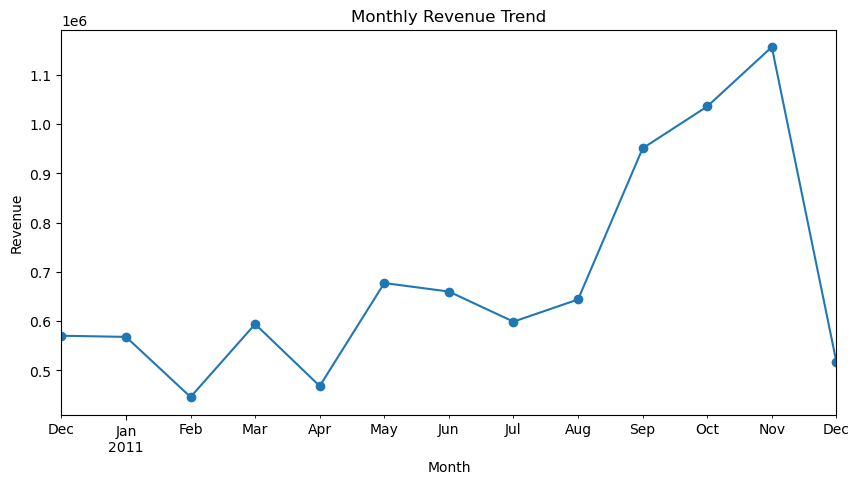

In [17]:
monthly_sales.plot(
    figsize=(10, 5),
    marker='o'
)

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

### Insight

Revenue increased strongly from September to November 2011, suggesting seasonal demand growth before the holiday period.

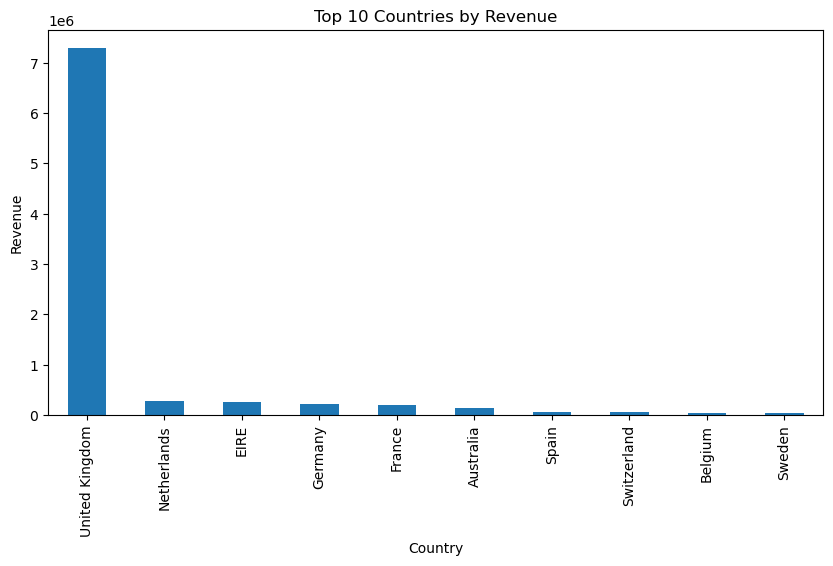

In [18]:
country_revenue.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')

plt.show()

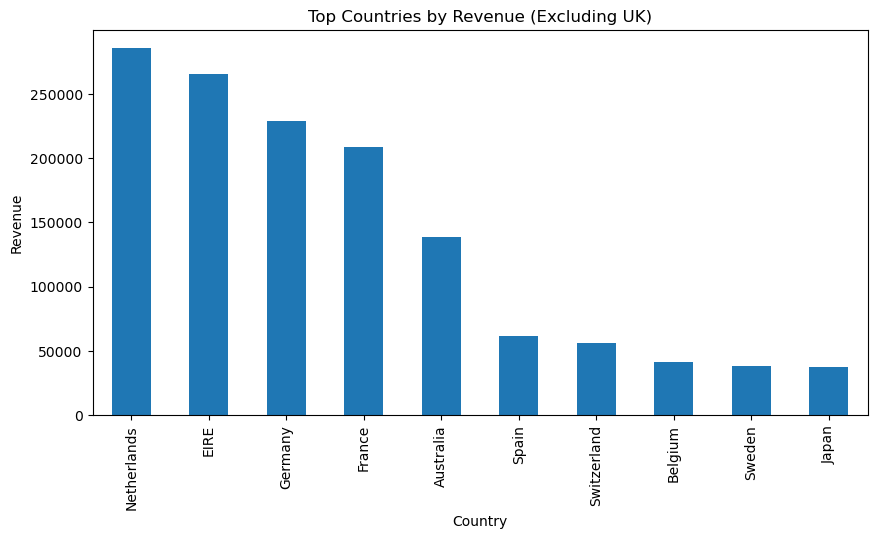

In [19]:
country_revenue_no_uk = country_revenue.drop('United Kingdom')

country_revenue_no_uk.head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top Countries by Revenue (Excluding UK)')
plt.xlabel('Country')
plt.ylabel('Revenue')

plt.show()

### Insight

The United Kingdom dominates total revenue. After excluding the UK, Netherlands, EIRE, Germany, and France are the strongest international markets.

In [20]:
# RFM analysis

max_date = df['InvoiceDate'].max()

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': 'max',
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['LastPurchaseDate', 'Frequency', 'Monetary']

rfm['Recency'] = (max_date - rfm['LastPurchaseDate']).dt.days

rfm.head()

,LastPurchaseDate,Frequency,Monetary,Recency
CustomerID,,,,
12346.0,2011-01-18 10:01:00,1,77183.60,325
12347.0,2011-12-07 15:52:00,7,4310.00,1
12348.0,2011-09-25 13:13:00,4,1797.24,74
12349.0,2011-11-21 09:51:00,1,1757.55,18
12350.0,2011-02-02 16:01:00,1,334.40,309


In [21]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5, 4, 3, 2, 1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1, 2, 3, 4, 5]
)

rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str)
    + rfm['F_Score'].astype(str)
    + rfm['M_Score'].astype(str)
)

rfm.head()

,LastPurchaseDate,Frequency,Monetary,Recency,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,,
12346.0,2011-01-18 10:01:00,1,77183.60,325,1,1,5,115
12347.0,2011-12-07 15:52:00,7,4310.00,1,5,5,5,555
12348.0,2011-09-25 13:13:00,4,1797.24,74,2,4,4,244
12349.0,2011-11-21 09:51:00,1,1757.55,18,4,1,4,414
12350.0,2011-02-02 16:01:00,1,334.40,309,1,1,2,112


In [22]:
# Rule-Based RFM Segmentation

rfm['Segment'] = 'Regular'

rfm.loc[
    (rfm['R_Score'] == 5) &
    (rfm['F_Score'] >= 4) &
    (rfm['M_Score'] >= 4),
    'Segment'
] = 'Champions'

rfm.loc[
    (rfm['R_Score'] >= 4) &
    (rfm['F_Score'] >= 3),
    'Segment'
] = 'Loyal Customers'

rfm.loc[
    (rfm['R_Score'] <= 2) &
    (rfm['F_Score'] <= 2),
    'Segment'
] = 'At Risk'

rfm['Segment'].value_counts()

Segment
Loyal Customers    1834
At Risk            1071
Regular             878
Champions           555
Name: count, dtype: int64

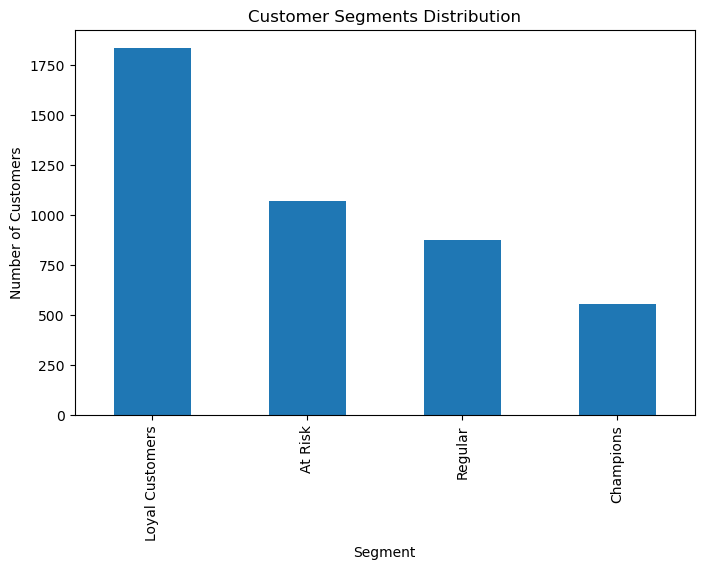

In [23]:
rfm['Segment'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Customer Segments Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

plt.show()

### Insight

Loyal Customers form the largest segment, while Champions represent a smaller but highly valuable customer group.

In [24]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_summary = rfm.groupby('Cluster')[
    ['Recency', 'Frequency', 'Monetary']
].mean()

cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,42.702685,3.682711,1353.625312
1,247.075914,1.552015,478.848773
2,6.384615,82.538462,127187.959231
3,14.500000,22.333333,12690.500392


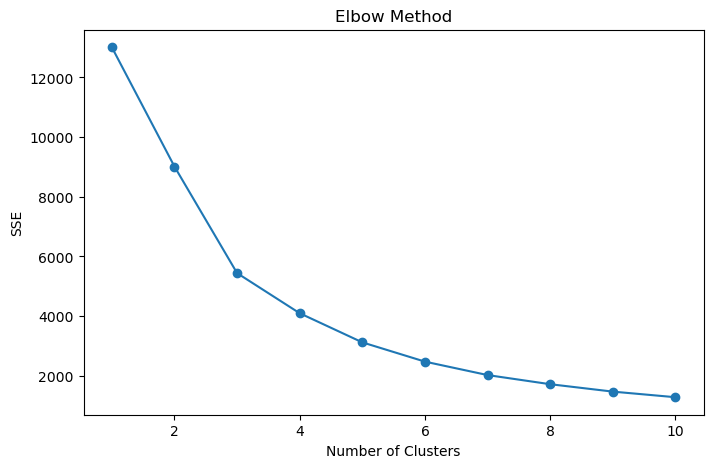

In [25]:
sse = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(rfm_scaled)

    sse.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    sse,
    marker='o'
)

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE')

plt.show()

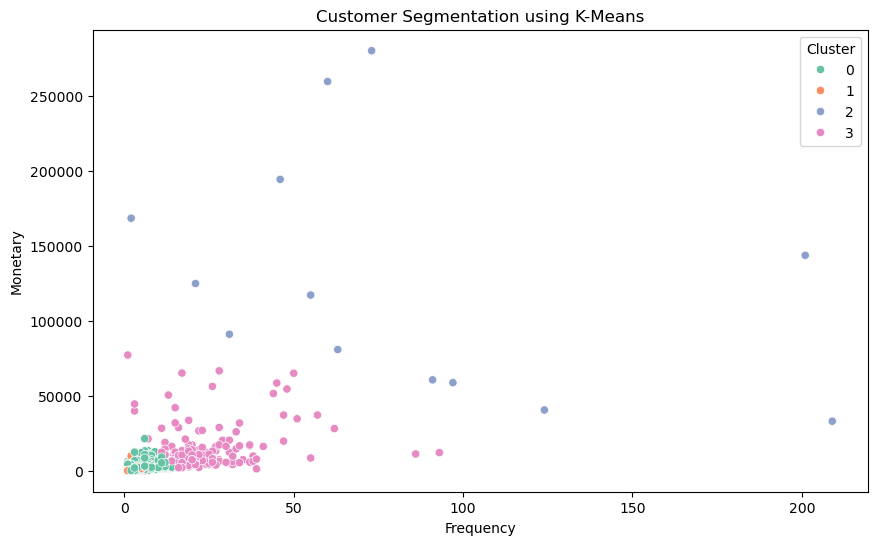

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='Set2'
)

plt.title('Customer Segmentation using K-Means')
plt.show()

### Insight

Cluster 2 represents the highest-value customers, characterized by high purchase frequency and strong monetary contribution.

These customers are prime candidates for loyalty programs and retention campaigns.

Cluster 1 consists of lower-value or less-engaged customers, showing lower purchase activity and spending levels.

Targeted promotions may help increase their engagement and lifetime value.